### Data Loading & Preprocessing

- GANs need normalized images (-1 to 1 or 0 to 1).
- Data augmentation prevents overfitting.

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),           # Convert to tensor (0-1)
    transforms.Normalize((0.5,), (0.5,))  # Scale to (-1, 1)
])

In [3]:
# Load CIFAR-10
train_data = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

Files already downloaded and verified


### Build the GAN (Generator & Discriminator)

- Generator: Creates fake images.
- Discriminator: Classifies real vs. fake.

In [4]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_channels * 32 * 32),  # CIFAR-10: 32x32x3
            nn.Tanh()  # Output in (-1, 1)
        )

    def forward(self, z):
        return self.model(z).view(-1, 3, 32, 32)

class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(img_channels * 32 * 32, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Binary classification
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

### Training Loop (with GPU Support)

- GANs need adversarial training.
- GPU speeds up computation.

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Initialize models
G = Generator().to(device)
D = Discriminator().to(device)

# Loss & Optimizers
criterion = nn.BCELoss()
G_optim = torch.optim.Adam(G.parameters(), lr=0.0002)
D_optim = torch.optim.Adam(D.parameters(), lr=0.0002)

# Training loop
for epoch in range(100):
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)
        
        # Train Discriminator
        D_optim.zero_grad()
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        
        # Real images loss
        real_preds = D(real_imgs)
        D_real_loss = criterion(real_preds, real_labels)
        
        # Fake images loss
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z)
        fake_preds = D(fake_imgs.detach())
        D_fake_loss = criterion(fake_preds, fake_labels)
        
        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_optim.step()
        
        # Train Generator
        G_optim.zero_grad()
        fake_preds = D(fake_imgs)
        G_loss = criterion(fake_preds, real_labels)  # Fool D
        G_loss.backward()
        G_optim.step()

In [6]:
torch.save(G.state_dict(), "generator.pth")


### Visualization & EDA

- Check if GAN is learning.
- Plot generated vs. real images.

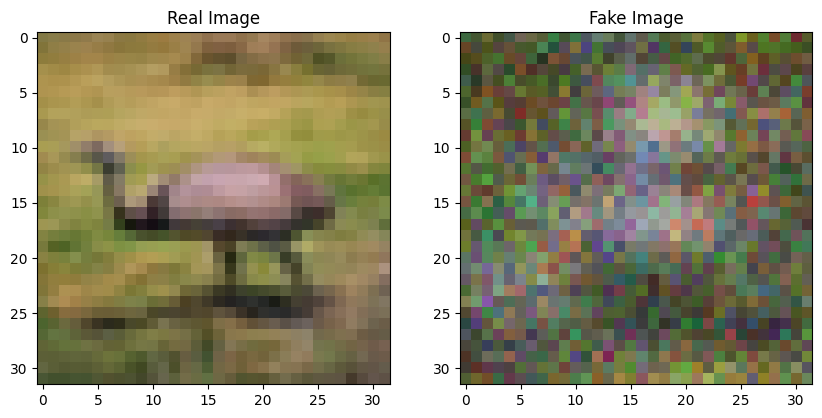

In [7]:
import matplotlib.pyplot as plt

def plot_images(real, fake):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(real[0].permute(1, 2, 0).cpu().detach().numpy() * 0.5 + 0.5)
    axes[0].set_title("Real Image")
    axes[1].imshow(fake[0].permute(1, 2, 0).cpu().detach().numpy() * 0.5 + 0.5)
    axes[1].set_title("Fake Image")
    plt.show()

# Generate & plot
z = torch.randn(1, 100).to(device)
fake_img = G(z)
plot_images(real_imgs[:1], fake_img)

## Build Diffusion Model

- Forward Process: Gradually adds noise to images.
- Reverse Process: Learns to denoise images.

In [8]:
import math

class SinusoidalPositionEmbeddings(nn.Module):
    """Adds time embeddings for diffusion steps."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Example U-Net architecture (simplified)
        self.time_embed = SinusoidalPositionEmbeddings(32)
        self.down = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.SiLU(),
        )
        self.up = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
        )

    def forward(self, x, t):
        # x: (B, 3, 32, 32), t: (B,)
        t_emb = self.time_embed(t)  # (B, 32)
        h = self.down(x)
        h = self.up(h)
        return h

## Training Loop (with GPU Support)

- Diffusion models require noise scheduling.
- GPU speeds up computation.

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Initialize model
model = DiffusionModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Noise scheduler
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

T = 1000  # Total timesteps
betas = linear_beta_schedule(T).to(device)

# Training loop
for epoch in range(100):
    for batch, _ in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Sample random timesteps
        t = torch.randint(0, T, (batch.size(0),)).to(device)

        # Add noise to images (forward process)
        noise = torch.randn_like(batch)
        sqrt_alpha = torch.sqrt(1 - betas[t]).view(-1, 1, 1, 1)
        noisy_images = sqrt_alpha * batch + torch.sqrt(betas[t]).view(-1, 1, 1, 1) * noise

        # Predict noise (reverse process)
        pred_noise = model(noisy_images, t)

        # Loss (mean squared error)
        loss = nn.functional.mse_loss(pred_noise, noise)
        loss.backward()
        optimizer.step()

## Sampling (Image Generation)

- Generate images by iterative denoising.

In [ ]:
@torch.no_grad()
def sample(model, image_size=32, batch_size=1, channels=3):
    # Start from pure noise
    img = torch.randn((batch_size, channels, image_size, image_size)).to(device)
    
    for t in reversed(range(T)):
        # Predict noise
        pred_noise = model(img, torch.full((batch_size,), t, device=device))
        
        # Remove noise
        img = (img - betas[t] * pred_noise / torch.sqrt(1 - betas[t])) / torch.sqrt(1 - betas[t])
        
    return img.clamp(-1, 1) * 0.5 + 0.5  # Rescale to (0, 1)